# YOUR PROJECT TITLE

> **Note the following:** 
> 1. This is *not* meant to be an example of an actual **data analysis project**, just an example of how to structure such a project.
> 1. Remember the general advice on structuring and commenting your code
> 1. The `dataproject.py` file includes a function which can be used multiple times in this notebook.

Imports and set magics:

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from matplotlib_venn import venn2

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2

# user written modules
import dataproject
import folium
import pycountry

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read and clean data

Import your data, either through an API or manually, and load it. 

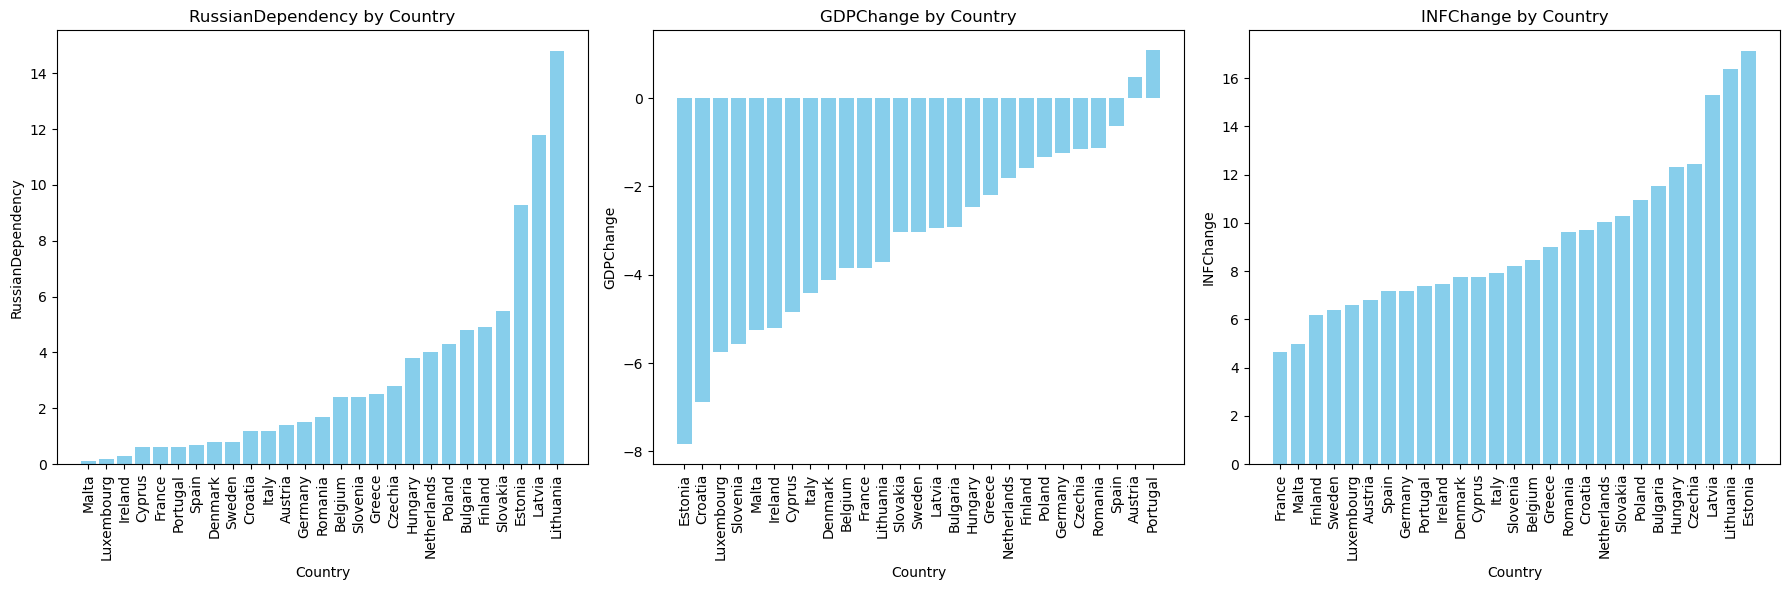

In [78]:
RDependency = pd.read_csv('RDependency.csv', sep=';')
RGDPChange = pd.read_csv('RGDPChange.csv', sep=';')
RINFChange = pd.read_csv('RINFChange.csv', sep=';')

RDependency['RussianDependency'] = RDependency['RussianDependency'].str.replace(',', '.')
RGDPChange['GDPChange'] = RGDPChange['GDPChange'].str.replace(',', '.')
RINFChange['INFChange'] = RINFChange['INFChange'].str.replace(',', '.')

RDependency['RussianDependency'] = pd.to_numeric(RDependency['RussianDependency'], errors='coerce')
RGDPChange['GDPChange'] = pd.to_numeric(RGDPChange['GDPChange'], errors='coerce')
RINFChange['INFChange'] = pd.to_numeric(RINFChange['INFChange'], errors='coerce')

merged_df = pd.merge(RDependency, RGDPChange, on='Country', how='inner')
final_merged_df = pd.merge(merged_df, RINFChange, on='Country', how='inner')

FinalDF = final_merged_df.round({'RussianDependency': 2, 'GDPChange': 2, 'INFChange': 2})

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


# Plot each variable, sorted by the values of that variable
variables = ['RussianDependency', 'GDPChange', 'INFChange']
for i, variable in enumerate(variables):
    # Sort the DataFrame by the current variable
    sorted_df = FinalDF.sort_values(by=variable)
    ax = axes[i]
    ax.bar(sorted_df['Country'], sorted_df[variable], color='skyblue')
    ax.set_xlabel('Country')
    ax.set_ylabel(variable)
    ax.set_title(f'{variable} by Country')
    ax.tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

In [79]:
# Define the lookup table for country coordinates
country_coordinates = {
    "Austria": (47.5162, 14.5501),
    "Belgium": (50.8503, 4.3517),
    "Bulgaria": (42.7339, 25.4858),
    "Croatia": (45.1, 15.2),
    "Cyprus": (35.1264, 33.4299),
    "Czech Republic": (49.8175, 15.4729),
    "Denmark": (56.2639, 9.5018),
    "Estonia": (58.5953, 25.0136),
    "Finland": (61.9241, 25.7482),
    "France": (46.6034, 1.8883),
    "Germany": (51.1657, 10.4515),
    "Greece": (39.0742, 21.8243),
    "Hungary": (47.1625, 19.5033),
    "Ireland": (53.1424, -7.6921),
    "Italy": (41.8719, 12.5674),
    "Latvia": (56.8796, 24.6032),
    "Lithuania": (55.1694, 23.8813),
    "Luxembourg": (49.8153, 6.1296),
    "Malta": (35.9375, 14.3754),
    "Netherlands": (52.1326, 5.2913),
    "Poland": (51.9194, 19.1451),
    "Portugal": (39.3999, -8.2245),
    "Romania": (45.9432, 24.9668),
    "Slovakia": (48.669, 19.699),
    "Slovenia": (46.1512, 14.9955),
    "Spain": (40.4637, -3.7492),
    "Sweden": (60.1282, 18.6435)
    # Add more countries and coordinates if needed
}# Assuming 'final_merged_df' is your DataFrame and already loaded with relevant data

# Initialize a map
m = folium.Map(location=[54, 15], tiles="OpenStreetMap", zoom_start=4)

# Function to create a popup for each country
def make_popup(country_row):
    return folium.Popup(f"Country: {country_row['Country']}<br>"
                        f"RussianDependency: {country_row['RussianDependency']}<br>"
                        f"GDPChange: {country_row['GDPChange']}<br>"
                        f"INFChange: {country_row['INFChange']}", max_width=300)

# Add markers to the map
for idx, row in FinalDF.iterrows():
    country = row['Country']
    coordinates = country_coordinates.get(country)
    if coordinates:
        folium.Marker(
            location=coordinates,
            popup=make_popup(row),
            icon=folium.Icon(color='blue', icon='info-sign')
        ).add_to(m)

# Display the map
m

To get a quick overview of the data, we show some **summary statistics** on a meaningful aggregation. 

MAKE FURTHER ANALYSIS. EXPLAIN THE CODE BRIEFLY AND SUMMARIZE THE RESULTS.

In [80]:
def get_country_code(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_2
    except LookupError:
        return None  # If a country is not found in the lookup

# Replace the country names with country codes in the DataFrame
FinalDF['Country_Code'] = FinalDF['Country'].apply(get_country_code)

# Drop rows where the country code could not be found (if necessary)
FinalDF = FinalDF.dropna(subset=['Country_Code'])


print(FinalDF)


        Country  RussianDependency  GDPChange  INFChange Country_Code
0       Austria                1.4       0.48       6.79           AT
1       Belgium                2.4      -3.84       8.47           BE
2      Bulgaria                4.8      -2.92      11.52           BG
3       Croatia                1.2      -6.89       9.72           HR
4        Cyprus                0.6      -4.85       7.77           CY
5       Czechia                2.8      -1.14      12.45           CZ
6       Denmark                0.8      -4.11       7.74           DK
7       Estonia                9.3      -7.84      17.12           EE
8       Finland                4.9      -1.57       6.17           FI
9        France                0.6      -3.84       4.66           FR
10      Germany                1.5      -1.24       7.18           DE
11       Greece                2.5      -2.20       9.01           GR
12      Hungary                3.8      -2.47      12.31           HU
13      Ireland     

In [83]:
import json

# Load GeoJSON file with country boundaries
with open('eu_countries.geojson', 'r') as f:
    country_geo = json.load(f)

# Initialize the map centered around a point
m = folium.Map(location=[54, 15], zoom_start=4)

# Create a Choropleth map where the color intensity is based on the inflation change (INFChange)
folium.Choropleth(
    geo_data=country_geo,  # GeoJSON containing the country boundaries
    name='choropleth',
    data=FinalDF,  # Your DataFrame
    columns=['Country_Code', 'INFChange'],  # Column names: country code and the value to color by
    key_on='feature.properties.NUTS_ID',  # Path in GeoJSON to match the country codes in your DataFrame
    fill_color='YlOrRd',  # Color scheme
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Inflation Change Rate (%)'
).add_to(m)

folium.LayerControl().add_to(m)

# Display the map
m

# Conclusion

ADD CONCISE CONLUSION.